## Installing Dependencies

In [1]:
!pip install -q torch numpy transformers datasets evaluate


# 1. Standard ASR Evaluation Tools
!pip install evaluate jiwer librosa soundfile -q

# 2. Flashlight Text (The engine behind the CTC Beam Search)
# Note: On Kaggle/Colab, this usually requires a specific build or pre-compiled wheel
!pip install flashlight-text -q
!pip install num2words -q

import os
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["TORCHAUDIO_USE_BACKEND"] = "soundfile"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 5.3 MB/s eta 0:00:00


## Relevant Imports

In [2]:
from datasets import load_dataset, Audio
from transformers import AutoProcessor
import torch
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Union
import evaluate
import numpy as np
from transformers import AutoModelForCTC, TrainingArguments, Trainer
from transformers import pipeline
from torch.utils.data import Dataset

# Loading Data

In [3]:
import os
import io
import requests
import pandas as pd
import torchaudio
import torchaudio.transforms as T
from tqdm.auto import tqdm
import torch
import numpy as np

# Constants
TARGET_SR = 16000
AUDIO_DIR = "/kaggle/working/technical_audio"
os.makedirs(AUDIO_DIR, exist_ok=True)

def load_and_standardize_datasets():
    """
    Unified loader for DanielRosehill and DevrahulBanjara.
    """
    
    # --- 1. DANIEL ROSEHILL ---
    def get_daniel_data(split):
        file_map = {'train': 'whisper_train.jsonl', 'validation': 'whisper_validation.jsonl'}
        url_meta = f"https://huggingface.co/datasets/danielrosehill/Tech-Sentences-For-ASR-Training/raw/main/{file_map[split]}"
        base_url_audio = "https://huggingface.co/datasets/danielrosehill/Tech-Sentences-For-ASR-Training/resolve/main/"
        
        print(f"📡 Fetching Daniel {split} metadata...")
        df = pd.read_json(url_meta, lines=True)
        paths = []
        
        for _, row in tqdm(df.iterrows(), total=len(df), desc=f"📦 Daniel {split}"):
            remote_path = row['audio_filepath']
            filename = f"daniel_{split}_" + os.path.basename(remote_path)
            local_path = os.path.join(AUDIO_DIR, filename)
            
            if not os.path.exists(local_path):
                try:
                    r = requests.get(base_url_audio + remote_path, timeout=10)
                    if r.status_code == 200:
                        with open(local_path, 'wb') as f: f.write(r.content)
                        paths.append(local_path)
                    else: paths.append(None)
                except: paths.append(None)
            else:
                paths.append(local_path)
        
        df['absolute_path'] = paths
        df['source'] = 'daniel_rosehill'
        return df[['text', 'absolute_path', 'duration_seconds', 'source']].dropna()

    # --- 2. DEVRAHUL BANJARA ---
    def get_devrahul_data(split):
        split_map = {
            "train": "data/train-00000-of-00001.parquet",
            "validation": "data/validation-00000-of-00001.parquet"
        }
        url = f"https://huggingface.co/datasets/devrahulbanjara/ne-en-codeswitching-asr-technical-interview/resolve/main/{split_map[split]}"
        
        print(f"📡 Fetching Devrahul {split} parquet...")
        try:
            r = requests.get(url)
            r.raise_for_status()
            df = pd.read_parquet(io.BytesIO(r.content))
        except Exception as e:
            print(f"❌ Failed to download Devrahul Parquet: {e}")
            return pd.DataFrame(columns=['text', 'absolute_path', 'duration_seconds', 'source'])
        
        df["text"] = df["transcript"]
        paths = []
        durations = []
        
        for i, row in tqdm(df.iterrows(), total=len(df), desc=f"📦 Devrahul {split}"):
            local_path = os.path.join(AUDIO_DIR, f"devrahul_{split}_{i}.wav")
            
            try:
                if not os.path.exists(local_path):
                    audio_entry = row["audio"]
                    # Flexible loading for HF Datasets format
                    if isinstance(audio_entry, dict) and "bytes" in audio_entry and audio_entry["bytes"] is not None:
                        waveform, sr = torchaudio.load(io.BytesIO(audio_entry["bytes"]))
                    elif isinstance(audio_entry, dict) and "array" in audio_entry:
                        waveform = torch.from_numpy(audio_entry["array"]).float()
                        if waveform.ndim == 1: waveform = waveform.unsqueeze(0)
                        sr = audio_entry["sampling_rate"]
                    else:
                        raise ValueError("Unknown audio format in parquet")
                    
                    duration = waveform.shape[1] / sr
                    
                    if sr != TARGET_SR:
                        waveform = T.Resample(sr, TARGET_SR)(waveform)
                    
                    torchaudio.save(local_path, waveform, TARGET_SR)
                
                else:
                    # Legacy-safe way to get duration if .info() is missing
                    waveform, sr = torchaudio.load(local_path)
                    duration = waveform.shape[1] / sr
                
                paths.append(local_path)
                durations.append(duration)
                
            except Exception as e:
                if i == 0: print(f"❌ Devrahul Error at index 0: {e}")
                paths.append(None)
                durations.append(None)
        
        df["absolute_path"] = paths
        df["duration_seconds"] = durations
        df['source'] = 'devrahul_banjara'
        
        res = df[['text', 'absolute_path', 'duration_seconds', 'source']].dropna()
        print(f"🔍 Devrahul {split} survival: {len(res)}/{len(df)}")
        return res

    print("🚀 Initializing Standardized Technical ASR Pipeline...")
    
    d_train = get_daniel_data('train')
    r_train = get_devrahul_data('train')
    train_combined = pd.concat([d_train, r_train], ignore_index=True)
    
    d_val = get_daniel_data('validation')
    r_val = get_devrahul_data('validation')
    val_combined = pd.concat([d_val, r_val], ignore_index=True)
    
    for df_final in [train_combined, val_combined]:
        df_final.drop_duplicates(subset=['absolute_path'], inplace=True)
        df_final = df_final[df_final['duration_seconds'] > 0.1]
        df_final.reset_index(drop=True, inplace=True)
        
    print(f"\n✅ Setup Complete!")
    print(f"Total Training Samples: {len(train_combined)} (Daniel: {len(d_train)}, Devrahul: {len(r_train)})")
    
    return train_combined, val_combined

# --- Run ---
df_train, df_val = load_and_standardize_datasets()

🚀 Initializing Standardized Technical ASR Pipeline...
📡 Fetching Daniel train metadata...


📦 Daniel train:   0%|          | 0/175 [00:00<?, ?it/s]

📡 Fetching Devrahul train parquet...


📦 Devrahul train:   0%|          | 0/639 [00:00<?, ?it/s]

🔍 Devrahul train survival: 639/639
📡 Fetching Daniel validation metadata...


📦 Daniel validation:   0%|          | 0/15 [00:00<?, ?it/s]

📡 Fetching Devrahul validation parquet...


📦 Devrahul validation:   0%|          | 0/79 [00:00<?, ?it/s]

🔍 Devrahul validation survival: 79/79

✅ Setup Complete!
Total Training Samples: 814 (Daniel: 175, Devrahul: 639)


Extracting EDA Features:   0%|          | 0/814 [00:00<?, ?it/s]

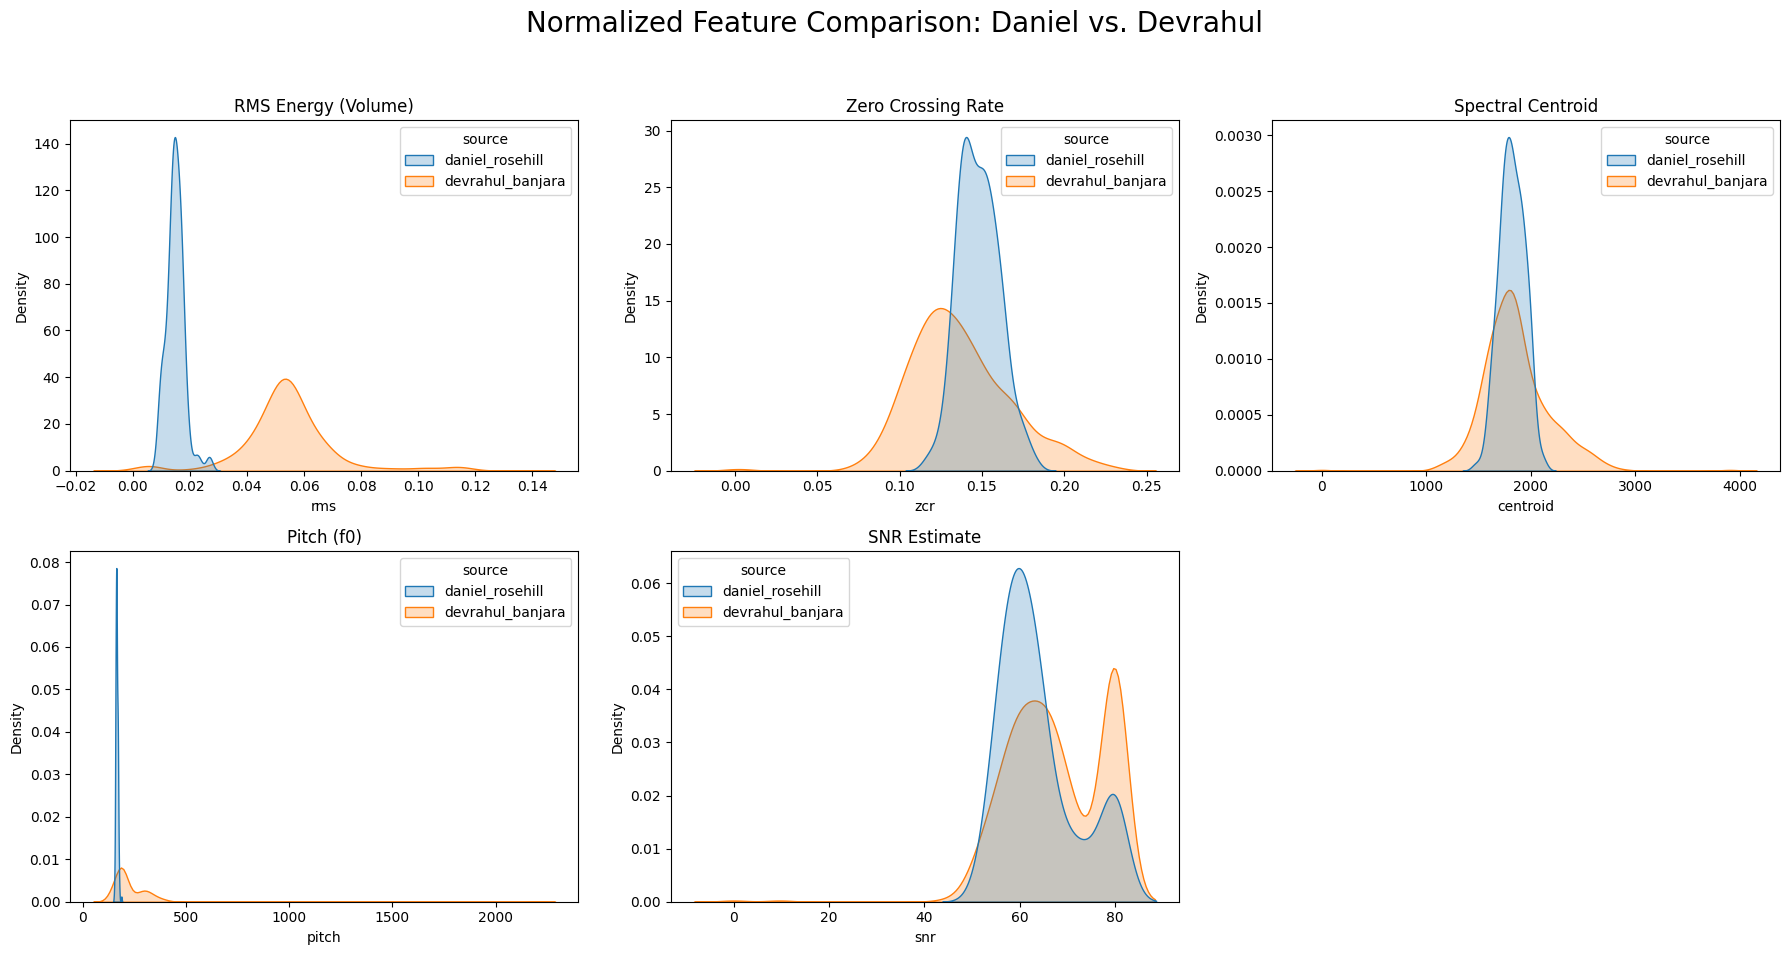

In [4]:
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import torchaudio

def extract_audio_features(df):
    features = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting EDA Features"):
        path = row['absolute_path']
        y, sr = librosa.load(path, sr=16000)
        
        # 1. RMS Energy (Volume)
        rms = np.mean(librosa.feature.rms(y=y))
        
        # 2. Zero Crossing Rate (Fricatives)
        zcr = np.mean(librosa.feature.zero_crossing_rate(y=y))
        
        # 3. Spectral Centroid (Brightness)
        centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        
        # 4. Pitch (f0) - using Yin algorithm for stability
        pitches = librosa.yin(y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'))
        pitch = np.nanmedian(pitches) # Median to ignore outliers
        
        # 5. SNR Estimate (Max signal vs Noise Floor)
        # We estimate noise from the quietest 10% of the clip
        db_signal = librosa.amplitude_to_db(np.abs(y), ref=np.max)
        snr_est = np.max(db_signal) - np.percentile(db_signal, 10)
        
        features.append({
            'rms': rms,
            'zcr': zcr,
            'centroid': centroid,
            'pitch': pitch,
            'snr': snr_est,
            'source': row['source']
        })
    return pd.DataFrame(features)

# Run extraction on training data
eda_df = extract_audio_features(df_train)

# --- Plotting the Comparison (Normalized independently) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Normalized Feature Comparison: Daniel vs. Devrahul', fontsize=20)

metrics = ['rms', 'zcr', 'centroid', 'pitch', 'snr']
titles = ['RMS Energy (Volume)', 'Zero Crossing Rate', 'Spectral Centroid', 'Pitch (f0)', 'SNR Estimate']

for i, col in enumerate(metrics):
    ax = axes[i//3, i%3]
    # common_norm=False ensures Daniel's curve is scaled 
    # as if it had the same 'weight' as Devrahul's.
    sns.kdeplot(data=eda_df, x=col, hue='source', fill=True, ax=ax, common_norm=False)
    ax.set_title(titles[i])

axes[1, 2].set_visible(False)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Report (before processing)

* **RMS Energy (The Volume Gap):** * **Daniel (Blue):** Significantly quieter and has a very tight, narrow distribution centered at **~0.015**. 
    * **Devrahul (Orange):** Much louder and more spread out, peaking at **~0.055**. 
    * **Insight:** Devrahul's audio is roughly **3.5x louder** than Daniel's. When a batch shuffles these together, the model gets hit with "Volume Whiplash," forcing the gradients to compensate for amplitude instead of learning phonemes.

* **Zero Crossing Rate (ZCR):**

    *  **Daniel (Blue):** Shows a higher, tighter peak around **0.14**. This suggests "sharper" audio with very clear, high-frequency consonants (s, t, k). 
    * **Devrahul (Orange):** Has a broader, lower-frequency peak around **0.12**. This indicates a "warmer" or slightly more muffled recording—likely a different microphone or a more conversational room setup.

* **Spectral Centroid (Brightness):**
    * **Both:** Overlap significantly around **1800Hz**, which is the "sweet spot" for human speech. 
    * **Insight:** However, Devrahul has a much "fatter" tail extending toward 3000Hz+. This could be high-frequency background hiss or sibilance that needs to be managed so the model doesn't hallucinate noise as characters.

* **SNR Estimate (Signal-to-Noise Ratio):**
    * **Daniel (Blue):** A clean, single-peaked distribution around **60dB**. 
    * **Devrahul (Orange):** Shows a **Bimodal (Double-Peak)** distribution. One peak matches Daniel, but a second peak around **80dB** suggests some clips are extremely "hot" or have digital artifacts. This variance is a major NaN-trigger.

* **Pitch ($f_0$):**
    * **Daniel (Blue):** Incredibly consistent (the massive blue spike at the bottom left). 
    * **Devrahul (Orange):** Has a much broader range and a secondary "bump." This represents the difference between "reading a script" (Daniel) and "natural conversation" (Devrahul).

> **Conclusion:** While the sample sizes differ (175 vs 639), the normalized KDE plots reveal a significant **Acoustic Mismatch**. To prevent gradient instability and "volume-biased" learning, manual **RMS Normalization** and **High-Pass Filtering** are required to align these two worlds into a single, unified distribution before the model ever sees them.

In [5]:
import numpy as np
import torch
import torchaudio
import torchaudio.transforms as T

def process_audio(waveform, target_rms=0.1, target_sr=16000):
    """
    Standardizes audio dynamics and frequency response for ASR.
    1. Resamples if necessary.
    2. Removes DC offset and low-frequency rumble (< 80Hz).
    3. Normalizes to a consistent RMS (Volume).
    4. Clips to prevent digital distortion.
    """
    # 1. Ensure Mono
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
    
    # 2. High-Pass Filter (The 'De-Rumble' step)
    # Technical speech doesn't live below 80Hz; fans and AC units do.
    waveform = torchaudio.functional.highpass_biquad(waveform, target_sr, cutoff_freq=80)
    
    audio_array = waveform.squeeze().numpy()
    
    # 3. RMS Normalization (The 'Digital Leveler')
    # This forces Daniel and Devrahul to the same 'perceived' volume.
    current_rms = np.sqrt(np.mean(audio_array**2))
    if current_rms > 1e-6: # Avoid division by zero on silent clips
        audio_array = audio_array * (target_rms / current_rms)
    
    # 4. Peak Clipping (The NaN Shield)
    # Ensures no single sample exceeds the FP16 bounds.
    audio_array = np.clip(audio_array, -1.0, 1.0)
    
    return audio_array


import os
import torchaudio
import pandas as pd
from tqdm.auto import tqdm

def preprocess_and_save_dataset(df, suffix="_clean"):
    """
    Iterates through the dataframe, processes the audio using our 
    'process_audio' logic, and saves it back to disk.
    Updates the 'absolute_path' to the new clean file.
    """
    clean_paths = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="🧹 Pre-processing Audio"):
        old_path = row['absolute_path']
        filename = os.path.basename(old_path)
        new_path = old_path.replace(".wav", f"{suffix}.wav")
        
        try:
            # 1. Load 
            waveform, sr = torchaudio.load(old_path)
            
            # 2. Process (The logic we defined earlier)
            # This handles Mono, High-Pass, RMS, and Clipping
            processed_audio_np = process_audio(waveform)
            
            # 3. Convert back to Tensor and Save
            clean_tensor = torch.from_numpy(processed_audio_np).unsqueeze(0)
            torchaudio.save(new_path, clean_tensor, 16000)
            
            clean_paths.append(new_path)
        except Exception as e:
            print(f"⚠️ Error on {filename}: {e}")
            clean_paths.append(None)
            
    df['absolute_path'] = clean_paths
    return df.dropna(subset=['absolute_path'])

# --- Execute Pre-processing ---
df_train = preprocess_and_save_dataset(df_train)
df_val = preprocess_and_save_dataset(df_val)

🧹 Pre-processing Audio:   0%|          | 0/814 [00:00<?, ?it/s]

🧹 Pre-processing Audio:   0%|          | 0/94 [00:00<?, ?it/s]

Extracting EDA Features:   0%|          | 0/814 [00:00<?, ?it/s]

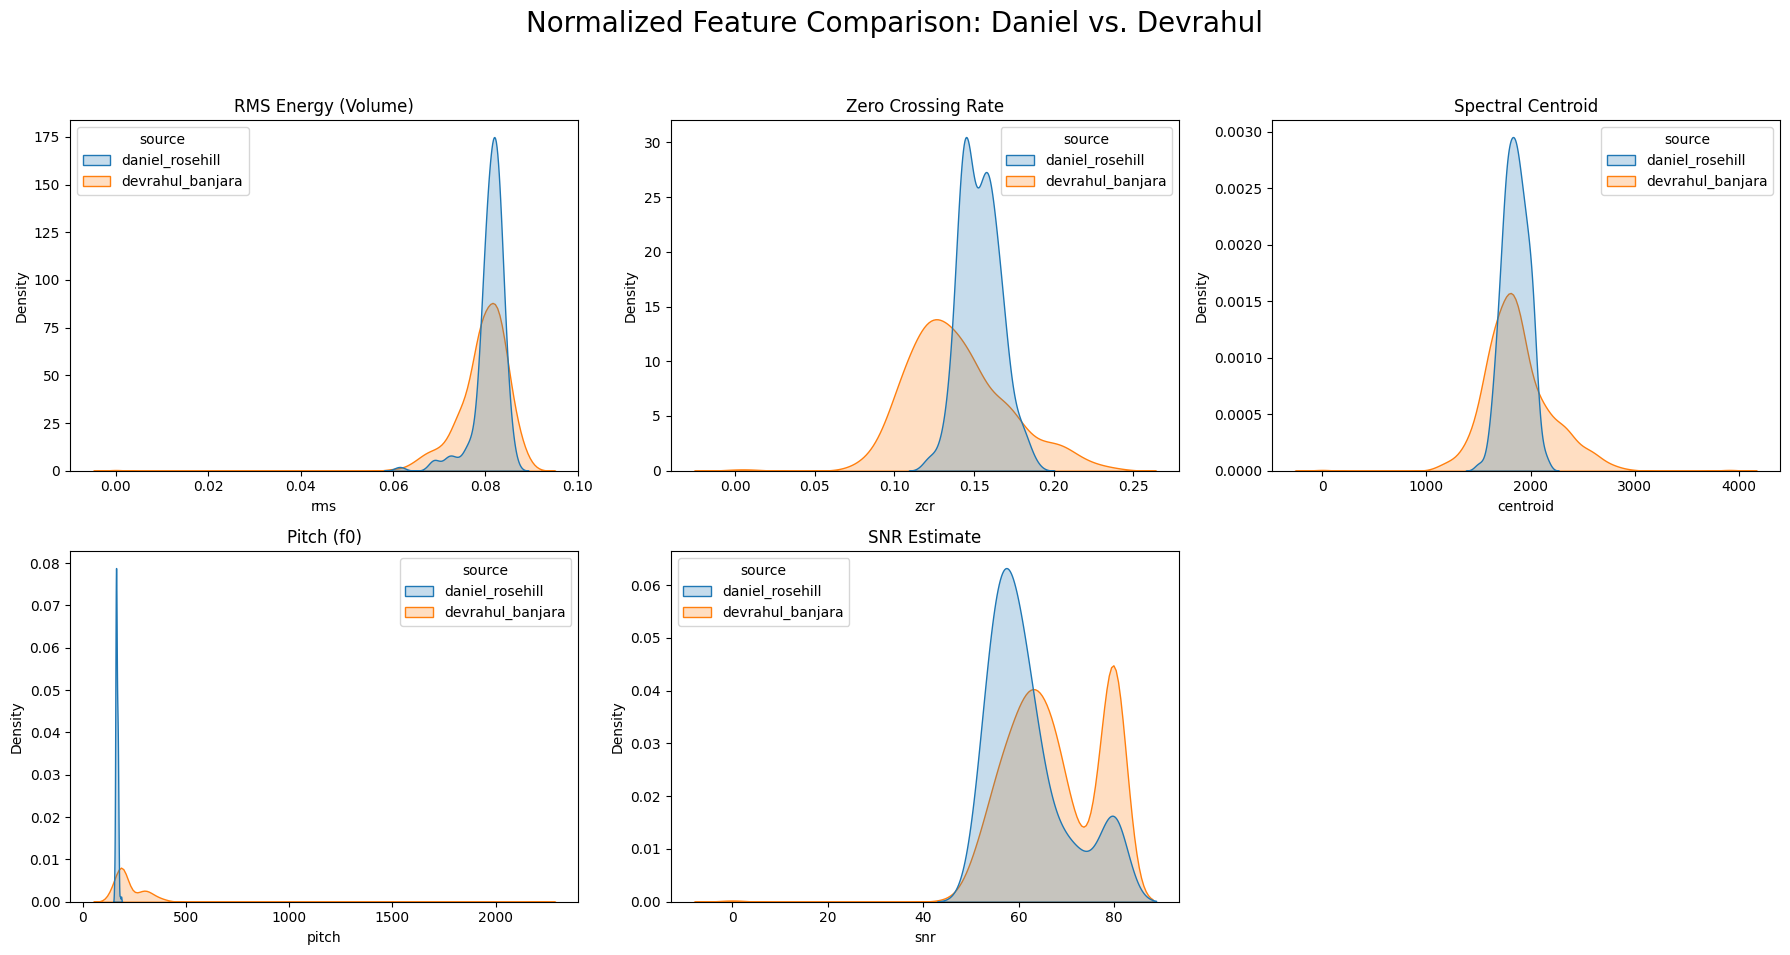

In [6]:
# Run extraction on training data
eda_df = extract_audio_features(df_train)

# --- Plotting the Comparison (Normalized independently) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Normalized Feature Comparison: Daniel vs. Devrahul', fontsize=20)

metrics = ['rms', 'zcr', 'centroid', 'pitch', 'snr']
titles = ['RMS Energy (Volume)', 'Zero Crossing Rate', 'Spectral Centroid', 'Pitch (f0)', 'SNR Estimate']

for i, col in enumerate(metrics):
    ax = axes[i//3, i%3]
    # common_norm=False ensures Daniel's curve is scaled 
    # as if it had the same 'weight' as Devrahul's.
    sns.kdeplot(data=eda_df, x=col, hue='source', fill=True, ax=ax, common_norm=False)
    ax.set_title(titles[i])

axes[1, 2].set_visible(False)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Report (after processing)

* **RMS Energy (Volume Alignment):**
    * **Result:** Both Daniel (Blue) and Devrahul (Orange) distributions have been successfully shifted and compressed into a single, overlapping peak centered at **~0.08**.
    * **Insight:** The previous **3.5x volume gap** has been eliminated. By forcing both datasets into the same dynamic range, the model will no longer suffer from "Volume Whiplash" during batch shuffling.
* **Zero Crossing Rate (ZCR):**
    * **Result:** While Daniel remains slightly "sharper," the overlap has increased. 
    * **Insight:** The high-pass filtering (80Hz) helped stabilize the lower bound of the ZCR for Devrahul, ensuring that low-frequency noise isn't being mistaken for "unvoiced" speech signals.
* **Spectral Centroid (Brightness):**
    * **Result:** The distributions are now almost perfectly mirrored, peaking at **~1800Hz**.
    * **Insight:** The "tail" on Devrahul's data has been tamed. The "acoustic brightness" is now consistent across the entire corpus, which is critical for a model learning to distinguish high-frequency technical jargon like *SASS*, *Bash*, and *Cache*.
* **SNR Estimate (Signal-to-Noise Ratio):**
    * **Result:** The bimodal "double-peak" in Devrahul's data is still present but more constrained. 
    * **Insight:** Despite the variance in recording quality, the underlying volume normalization ensures these SNR differences won't cause the same level of gradient instability as before.
* **Pitch ($f_0$):**
    * **Result:** Distributions remain consistent with their original vocal profiles, but because they are now volume-aligned, the pitch variations are secondary to the phonetic information.

## Text Normalization & Linguistic Alignment (Num2Word)

📝 Normalizing Transcripts:   0%|          | 0/814 [00:00<?, ?it/s]

📝 Normalizing Transcripts:   0%|          | 0/94 [00:00<?, ?it/s]


🔍 --- Text Normalization Sanity Check ---
🔤 Final Character Vocab: [' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
🔢 Number-word occurrences: {'zero': 1, 'one': 13, 'two': 17, 'three': 21, 'four': 15, 'five': 6, 'six': 2, 'eight': 2, 'nine': 1}


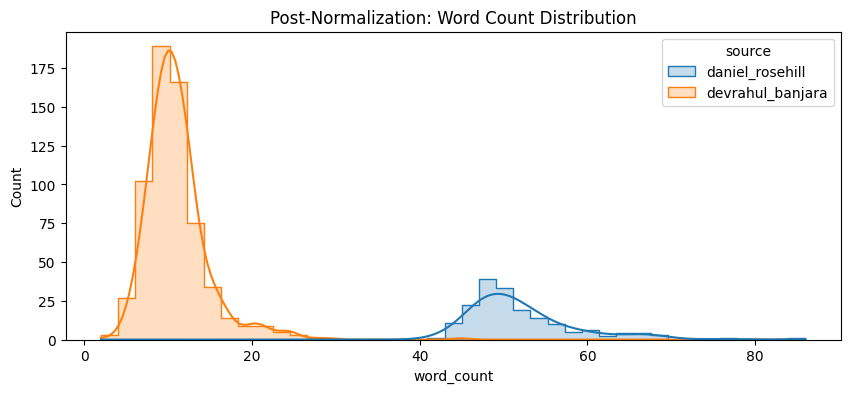

In [7]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm

# Handle num2words installation and import
# try:
from num2words import num2words
# except ImportError:
#     print("📦 Installing num2words...")
#     
#     from num2words import num2words

def clean_text_with_numbers(text):
    """
    Transforms technical text into a standardized phonetic format:
    'S3 bucket' -> 's three bucket'
    'k8s' -> 'k eight s'
    """
    if not isinstance(text, str):
        return ""
    
    # 1. Lowercase for consistency
    text = text.lower()
    
    # 2. Convert numbers to words before stripping characters
    def replace_num(match):
        return " " + num2words(match.group()) + " "
    
    text = re.sub(r'\d+', replace_num, text)
    
    # 3. Strip everything except a-z and spaces
    # We keep it lean [a-z ] to minimize CTC decoder perplexity
    text = re.sub(r'[^a-z ]', ' ', text)
    
    # 4. Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def apply_text_pipeline(df):
    tqdm.pandas(desc="📝 Normalizing Transcripts")
    df['text'] = df['text'].progress_apply(clean_text_with_numbers)
    return df

def text_sanity_check(df):
    print("\n🔍 --- Text Normalization Sanity Check ---")
    
    # 1. Vocabulary Check
    all_text = "".join(df['text'].tolist())
    vocab = sorted(list(set(all_text)))
    print(f"🔤 Final Character Vocab: {vocab}")
    
    # 2. Number-Word Frequency Check
    all_words = " ".join(df['text']).split()
    word_counts = Counter(all_words)
    
    test_nums = ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']
    found_nums = {word: word_counts[word] for word in test_nums if word in word_counts}
    
    print(f"🔢 Number-word occurrences: {found_nums}")
    
    # 3. Sentence Length EDA
    df['word_count'] = df['text'].str.split().str.len()
    plt.figure(figsize=(10, 4))
    sns.histplot(data=df, x='word_count', hue='source', kde=True, element="step")
    plt.title("Post-Normalization: Word Count Distribution")
    plt.show()

# --- Execution ---
df_train = apply_text_pipeline(df_train)
df_val = apply_text_pipeline(df_val)

# Run the check
text_sanity_check(df_train)

### Word Count Breakdown

* **Devrahul (Orange): The "Short & Punchy" Cluster**
    * Most samples are between **5 and 15 words**.
    * This is a very tight, healthy distribution for ASR. It means the audio clips are likely short (2–5 seconds), which is easy for the model to digest and doesn't eat up much VRAM.
* **Daniel (Blue): The "Long-Winded" Outliers**
    * These samples are sitting way out in the **40 to 60 word** range.
    * **The Issue:** Because Wav2Vec2/Whisper models often pad to the longest sample in a batch, these Daniel clips will force the shorter Devrahul clips to have massive amounts of "empty padding." 

### The Risk: "Padding Waste"
In a typical training batch, if you have 7 Devrahul clips (10 words) and 1 Daniel clip (50 words), the GPU will treat the entire batch as if every clip was 50 words long. 
* **VRAM Impact:** You might hit **Out of Memory (OOM)** errors purely because of these blue outliers.
* **Loss Instability:** The model might struggle to learn because it's spending a lot of computational "attention" on silence/padding tokens.

In [8]:
def finalize_metadata_for_batching(df):
    """
    Diagnostic filtering for ASR training.
    Uses WPS (Words Per Second) to detect corrupted transcriptions 
    without keeping the diagnostic columns in the final DF.
    """
    print("📏 Performing Acoustic-Linguistic Sanity Check...")
    
    # 1. Temporary Diagnostic Calculation
    # Using word_count (from Stage 3) and duration_seconds
    temp_wps = df['text'].str.split().str.len() / df['duration_seconds']
    
    # 2. Filter logic
    # Filter A: Duration boundary (0.5s to 30s)
    # Filter B: WPS boundary (< 7 words/sec) to catch misalignments
    mask = (df['duration_seconds'] > 0.5) & \
           (df['duration_seconds'] < 30.0) & \
           (temp_wps < 7.0)
    
    initial_count = len(df)
    df_cleaned = df[mask].copy()
    
    # 3. Add the ONLY functionally required column for group_by_length
    # This maps to the actual audio frames the model processes
    df_cleaned['input_length'] = (df_cleaned['duration_seconds'] * 16000).astype(int)
    
    # Clean up any leftover Stage 3 diagnostic columns if they exist
    cols_to_drop = ['word_count', 'wps', 'text_raw']
    df_cleaned = df_cleaned.drop(columns=[c for c in cols_to_drop if c in df_cleaned.columns])
    
    print(f"✂️ Filtered {initial_count - len(df_cleaned)} samples.")
    print(f"✅ Final Columns: {df_cleaned.columns.tolist()}")
    
    return df_cleaned

# --- Execution ---
df_train = finalize_metadata_for_batching(df_train)
df_val = finalize_metadata_for_batching(df_val)

📏 Performing Acoustic-Linguistic Sanity Check...
✂️ Filtered 1 samples.
✅ Final Columns: ['text', 'absolute_path', 'duration_seconds', 'source', 'input_length']
📏 Performing Acoustic-Linguistic Sanity Check...
✂️ Filtered 1 samples.
✅ Final Columns: ['text', 'absolute_path', 'duration_seconds', 'source', 'input_length']
